# Pre-DRR Preprocessing Pipeline

This notebook standardizes raw DICOM CT volumes into a uniform format suitable for **Digitally Reconstructed Radiograph (DRR)** generation.

**Pipeline stages:**
1. Data discovery & filtering
2. Quality checks
3. Spatial resampling (0.5mm isotropic)
4. Orientation standardization (LAS)
5. Bone windowing ([-450, 1050] HU)
6. ROI tight bone crop
7. Resize to 256×256×256
8. Export as NIfTI

## Cell 1 — Imports & Configuration

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import ndimage

# MONAI
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    Orientationd,
    ScaleIntensityRanged,
    Resized,
    CropForegroundd,
)

# ============================================================
# Configuration
# ============================================================
PROJECT_ROOT = Path(r"c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject")

# Raw data paths
RAW_FRACTURED_LEFT  = PROJECT_ROOT / "data" / "raw" / "fractured" / "PartLeft"
RAW_FRACTURED_RIGHT = PROJECT_ROOT / "data" / "raw" / "fractured" / "PartRight"
RAW_HEALTHY         = PROJECT_ROOT / "data" / "raw" / "healthy"  # placeholder

# Output
OUTPUT_DIR = PROJECT_ROOT / "data" / "interim" / "predrr"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Target parameters (temporary — will be adjusted later)
TARGET_SPACING = (0.5, 0.5, 0.5)   # mm isotropic
TARGET_SIZE    = (256, 256, 256)    # voxels

# Bone windowing (preserves cortical details)
HU_MIN = -450
HU_MAX = 1050

# Scout filter: minimum number of Z-slices to be considered a valid volume
MIN_Z_SLICES = 10

# ROI crop parameters
ROI_INTENSITY_THRESHOLD = 0.1   # fraction of normalized range
ROI_CLOSING_RADIUS      = 3     # morphological closing ball radius (voxels)
ROI_PAD_MARGIN           = 5     # padding voxels around bounding box

print("Configuration loaded.")
print(f"  Target spacing : {TARGET_SPACING} mm")
print(f"  Target size    : {TARGET_SIZE} voxels")
print(f"  Bone window    : [{HU_MIN}, {HU_MAX}] HU")
print(f"  Output dir     : {OUTPUT_DIR}")

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Configuration loaded.
  Target spacing : (0.5, 0.5, 0.5) mm
  Target size    : (256, 256, 256) voxels
  Bone window    : [-450, 1050] HU
  Output dir     : c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\interim\predrr


## Cell 2 — Data Discovery & Case Registry

In [2]:
def discover_cases(base_dir, part_name):
    """Scan a directory for DICOM case folders and extract metadata."""
    cases = []
    if not base_dir.exists():
        print(f"  [WARN] Directory not found: {base_dir}")
        return cases

    for case_dir in sorted(base_dir.iterdir()):
        if not case_dir.is_dir():
            continue

        reader = sitk.ImageSeriesReader()
        dicom_names = reader.GetGDCMSeriesFileNames(str(case_dir))

        if not dicom_names:
            cases.append({
                "case_id": case_dir.name, "part": part_name,
                "case_path": str(case_dir), "valid": False,
                "filter_reason": "No DICOM files found",
                "size": None, "spacing": None,
            })
            continue

        reader.SetFileNames(dicom_names)
        try:
            img = reader.Execute()
            size = img.GetSize()
            spacing = img.GetSpacing()

            valid = size[2] >= MIN_Z_SLICES
            reason = None if valid else f"Only {size[2]} Z-slice(s) (scout/localizer)"

            cases.append({
                "case_id": case_dir.name, "part": part_name,
                "case_path": str(case_dir), "valid": valid,
                "filter_reason": reason,
                "size": size, "spacing": spacing,
            })
        except Exception as e:
            cases.append({
                "case_id": case_dir.name, "part": part_name,
                "case_path": str(case_dir), "valid": False,
                "filter_reason": f"Read error: {e}",
                "size": None, "spacing": None,
            })
    return cases


print("Scanning for DICOM cases...")
all_cases = []
all_cases.extend(discover_cases(RAW_FRACTURED_LEFT, "PartLeft"))
all_cases.extend(discover_cases(RAW_FRACTURED_RIGHT, "PartRight"))

df_cases = pd.DataFrame(all_cases)
df_valid   = df_cases[df_cases["valid"] == True].reset_index(drop=True)
df_invalid = df_cases[df_cases["valid"] == False].reset_index(drop=True)

print(f"\nTotal cases found   : {len(df_cases)}")
print(f"Valid cases         : {len(df_valid)}")
print(f"Filtered out        : {len(df_invalid)}")

if len(df_invalid) > 0:
    print("\n--- Filtered Cases ---")
    display(df_invalid[["case_id", "part", "filter_reason"]])

print("\n--- Valid Cases ---")
display(df_valid[["case_id", "part", "size", "spacing"]])

Scanning for DICOM cases...

Total cases found   : 16
Valid cases         : 14
Filtered out        : 2

--- Filtered Cases ---


,case_id,part,filter_reason
0,Case4,PartLeft,Only 1 Z-slice(s) (scout/localizer)
1,Case10,PartRight,Only 1 Z-slice(s) (scout/localizer)



--- Valid Cases ---


,case_id,part,size,spacing
0,Case1,PartLeft,"(512, 512, 103)","(0.4296875, 0.4296875, 3.0)"
1,Case2,PartLeft,"(512, 512, 85)","(0.4296875, 0.4296875, 3.0)"
2,Case3,PartLeft,"(512, 512, 82)","(0.38671875, 0.38671875, 3.0)"
3,Case11,PartRight,"(512, 512, 340)","(0.3671875, 0.3671875, 0.6999999999999998)"
4,Case12,PartRight,"(512, 512, 397)","(0.447265625, 0.447265625, 0.7000000000000001)"
5,Case13,PartRight,"(512, 512, 361)","(0.466796875, 0.466796875, 0.7)"
6,Case14,PartRight,"(512, 512, 418)","(0.390625, 0.390625, 0.6999999999999996)"
7,Case15,PartRight,"(512, 512, 71)","(0.365234375, 0.365234375, 3.0)"
8,Case16,PartRight,"(512, 512, 337)","(0.427734375, 0.427734375, 0.6999999999999998)"
9,Case5,PartRight,"(512, 512, 72)","(0.3828125, 0.3828125, 3.0)"


## Cell 3 — Raw Data Quality Check

Running quality checks on valid cases...



,case_id,part,HU_min,HU_max,phys_X_mm,phys_Y_mm,phys_Z_mm
0,Case1,PartLeft,-1024.0,2285.0,220.0,220.0,309.0
1,Case2,PartLeft,-1024.0,2166.0,220.0,220.0,255.0
2,Case3,PartLeft,-1024.0,1992.0,198.0,198.0,246.0
3,Case11,PartRight,-1024.0,3031.0,188.0,188.0,238.0
4,Case12,PartRight,-1024.0,3069.0,229.0,229.0,277.9
5,Case13,PartRight,-1024.0,3052.0,239.0,239.0,252.7
6,Case14,PartRight,-1024.0,1879.0,200.0,200.0,292.6
7,Case15,PartRight,-1024.0,2074.0,187.0,187.0,213.0
8,Case16,PartRight,-1024.0,1821.0,219.0,219.0,235.9
9,Case5,PartRight,-1024.0,2181.0,196.0,196.0,216.0



✅ All cases have expected HU ranges.


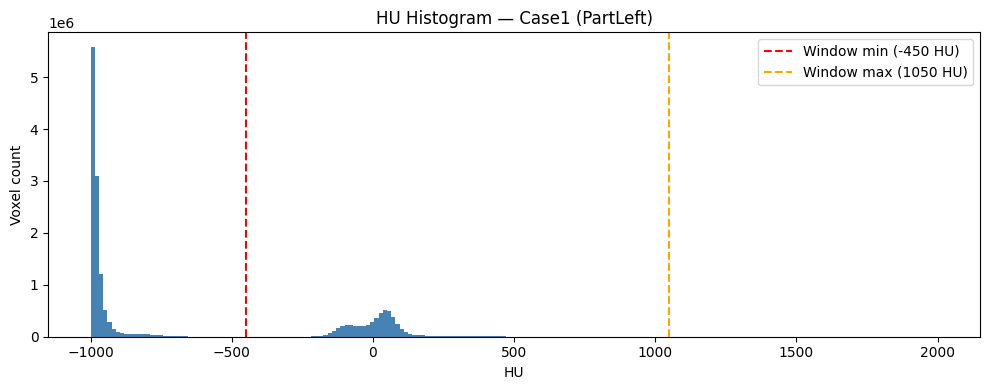

In [3]:
def load_sitk_volume(case_path):
    """Load a DICOM series as a SimpleITK image."""
    reader = sitk.ImageSeriesReader()
    dicom_names = reader.GetGDCMSeriesFileNames(case_path)
    reader.SetFileNames(dicom_names)
    return reader.Execute()


print("Running quality checks on valid cases...\n")
qc_records = []

for idx, row in df_valid.iterrows():
    img = load_sitk_volume(row["case_path"])
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    spacing = img.GetSpacing()
    size = img.GetSize()

    phys_dims = tuple(round(s * sp, 1) for s, sp in zip(size, spacing))

    qc_records.append({
        "case_id": row["case_id"],
        "part": row["part"],
        "HU_min": float(arr.min()),
        "HU_max": float(arr.max()),
        "phys_X_mm": phys_dims[0],
        "phys_Y_mm": phys_dims[1],
        "phys_Z_mm": phys_dims[2],
    })

df_qc = pd.DataFrame(qc_records)
display(df_qc)

# Flag anomalies
anomalies = df_qc[(df_qc["HU_min"] > 0) | (df_qc["HU_max"] < 200)]
if len(anomalies) > 0:
    print("\n⚠️  Anomalous HU ranges detected:")
    display(anomalies)
else:
    print("\n✅ All cases have expected HU ranges.")

# HU histogram for first valid case
sample_img = load_sitk_volume(df_valid.iloc[0]["case_path"])
sample_arr = sitk.GetArrayFromImage(sample_img).astype(np.float32).flatten()

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.hist(sample_arr, bins=200, range=(-1000, 2000), color="steelblue", edgecolor="none")
ax.axvline(HU_MIN, color="red", ls="--", label=f"Window min ({HU_MIN} HU)")
ax.axvline(HU_MAX, color="orange", ls="--", label=f"Window max ({HU_MAX} HU)")
ax.set_xlabel("HU")
ax.set_ylabel("Voxel count")
ax.set_title(f"HU Histogram — {df_valid.iloc[0]['case_id']} ({df_valid.iloc[0]['part']})")
ax.legend()
plt.tight_layout()
plt.show()

## Cell 4 — Spatial Standardization (Resampling to 0.5mm Isotropic)

Case: Case1 (PartLeft)
  Original  — size: (512, 512, 103), spacing: (0.4297, 0.4297, 3.0)
  Resampled — size: (440, 440, 618), spacing: (0.5, 0.5, 0.5)


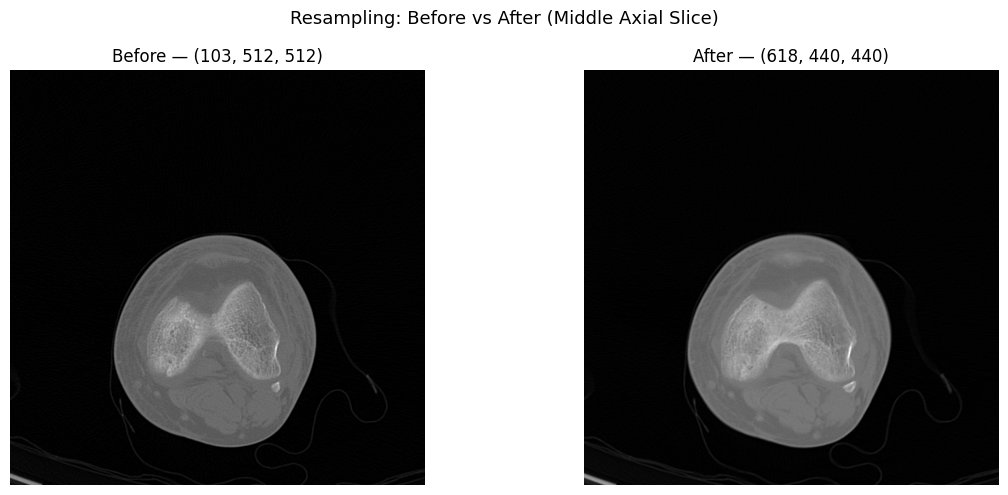

In [4]:
def resample_volume(sitk_img, new_spacing=TARGET_SPACING):
    """Resample a SimpleITK image to the target isotropic spacing."""
    original_spacing = sitk_img.GetSpacing()
    original_size    = sitk_img.GetSize()

    new_size = [
        int(round(osz * osp / nsp))
        for osz, osp, nsp in zip(original_size, original_spacing, new_spacing)
    ]

    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(new_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(sitk_img.GetDirection())
    resampler.SetOutputOrigin(sitk_img.GetOrigin())
    resampler.SetTransform(sitk.Transform())
    resampler.SetDefaultPixelValue(sitk_img.GetPixelIDValue())
    resampler.SetInterpolator(sitk.sitkLinear)

    return resampler.Execute(sitk_img)


# Demo: resample first valid case and visualize before/after
demo_row = df_valid.iloc[0]
demo_img = load_sitk_volume(demo_row["case_path"])
demo_resampled = resample_volume(demo_img)

print(f"Case: {demo_row['case_id']} ({demo_row['part']})")
print(f"  Original  — size: {demo_img.GetSize()}, spacing: {tuple(round(s,4) for s in demo_img.GetSpacing())}")
print(f"  Resampled — size: {demo_resampled.GetSize()}, spacing: {demo_resampled.GetSpacing()}")

# Visualize middle axial slice before/after
arr_before = sitk.GetArrayFromImage(demo_img)
arr_after  = sitk.GetArrayFromImage(demo_resampled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(arr_before[arr_before.shape[0]//2], cmap="gray")
axes[0].set_title(f"Before — {arr_before.shape}")
axes[0].axis("off")
axes[1].imshow(arr_after[arr_after.shape[0]//2], cmap="gray")
axes[1].set_title(f"After — {arr_after.shape}")
axes[1].axis("off")
plt.suptitle("Resampling: Before vs After (Middle Axial Slice)", fontsize=13)
plt.tight_layout()
plt.show()

## Cell 5 — Orientation Standardization (LAS)

In [5]:
def orient_to_las(sitk_img):
    """Reorient a SimpleITK image to LAS (Left-Anterior-Superior) orientation."""
    orienter = sitk.DICOMOrientImageFilter()
    orienter.SetDesiredCoordinateOrientation("LAS")
    return orienter.Execute(sitk_img)


# Demo
demo_oriented = orient_to_las(demo_resampled)
print(f"Direction before: {tuple(round(d,2) for d in demo_resampled.GetDirection())}")
print(f"Direction after : {tuple(round(d,2) for d in demo_oriented.GetDirection())}")
print(f"Size after orient: {demo_oriented.GetSize()}")

Direction before: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
Direction after : (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)
Size after orient: (440, 440, 618)


## Cell 6 — Radiometric Standardization (Bone Windowing)

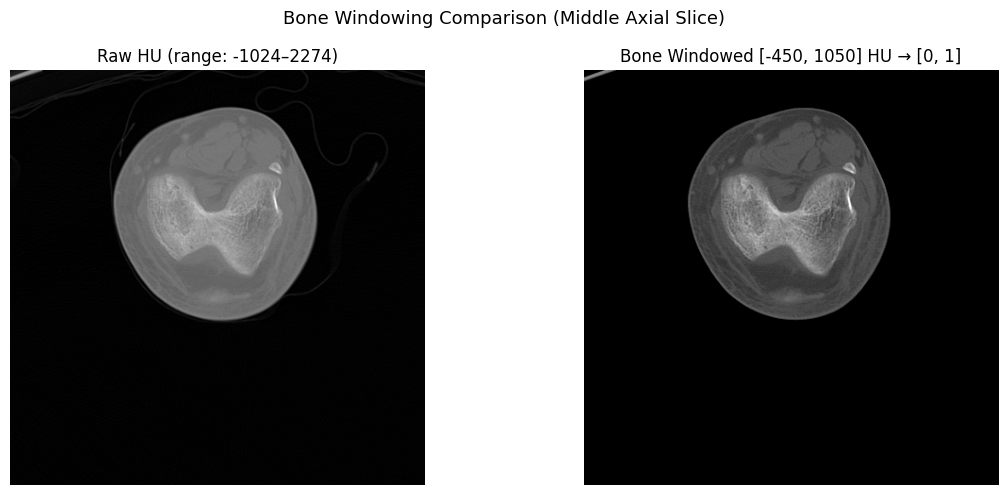

Windowed intensity range: [0.0000, 1.0000]


In [6]:
def apply_bone_window(arr, hu_min=HU_MIN, hu_max=HU_MAX):
    """Clip to bone window and normalize to [0, 1]."""
    arr = np.clip(arr, hu_min, hu_max)
    arr = (arr - hu_min) / (hu_max - hu_min)
    return arr.astype(np.float32)


# Demo: visualize raw vs windowed
demo_arr_raw = sitk.GetArrayFromImage(demo_oriented).astype(np.float32)
demo_arr_windowed = apply_bone_window(demo_arr_raw)

mid_z = demo_arr_raw.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(demo_arr_raw[mid_z], cmap="gray")
axes[0].set_title(f"Raw HU (range: {demo_arr_raw.min():.0f}–{demo_arr_raw.max():.0f})")
axes[0].axis("off")
axes[1].imshow(demo_arr_windowed[mid_z], cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Bone Windowed [{HU_MIN}, {HU_MAX}] HU → [0, 1]")
axes[1].axis("off")
plt.suptitle("Bone Windowing Comparison (Middle Axial Slice)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Windowed intensity range: [{demo_arr_windowed.min():.4f}, {demo_arr_windowed.max():.4f}]")

## Cell 7 — ROI Cropping (Tight Bone-Region Crop)

Before crop: (618, 440, 440)
After crop : (618, 306, 293)
Bounding box (z,y,x min/max): (0, np.int64(4), np.int64(101), 618, np.int64(310), np.int64(394))


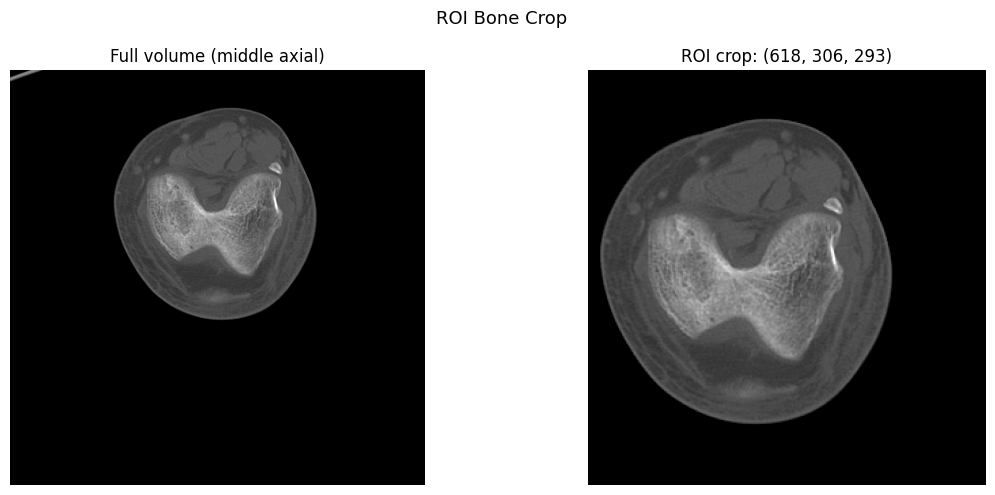

In [7]:
def roi_bone_crop(arr_windowed, threshold=ROI_INTENSITY_THRESHOLD,
                  closing_radius=ROI_CLOSING_RADIUS, pad=ROI_PAD_MARGIN):
    """
    Tight crop around bone anatomy.
    1. Threshold windowed volume to create binary mask
    2. Morphological closing to fill gaps
    3. Keep largest connected component
    4. Bounding box + padding
    """
    # Step 1: binary mask
    mask = (arr_windowed > threshold).astype(np.uint8)

    # Step 2: morphological closing
    struct = ndimage.generate_binary_structure(3, 1)
    struct = ndimage.iterate_structure(struct, closing_radius)
    mask = ndimage.binary_closing(mask, structure=struct).astype(np.uint8)

    # Step 3: largest connected component
    labeled, num_features = ndimage.label(mask)
    if num_features == 0:
        print("  [WARN] No foreground detected, returning full volume.")
        return arr_windowed, (0, 0, 0, arr_windowed.shape[0], arr_windowed.shape[1], arr_windowed.shape[2])

    component_sizes = ndimage.sum(mask, labeled, range(1, num_features + 1))
    largest_label = np.argmax(component_sizes) + 1
    mask = (labeled == largest_label).astype(np.uint8)

    # Step 4: bounding box + padding
    coords = np.argwhere(mask)
    z_min, y_min, x_min = coords.min(axis=0)
    z_max, y_max, x_max = coords.max(axis=0) + 1  # exclusive end

    # Apply padding (clamped to volume bounds)
    z_min = max(0, z_min - pad)
    y_min = max(0, y_min - pad)
    x_min = max(0, x_min - pad)
    z_max = min(arr_windowed.shape[0], z_max + pad)
    y_max = min(arr_windowed.shape[1], y_max + pad)
    x_max = min(arr_windowed.shape[2], x_max + pad)

    cropped = arr_windowed[z_min:z_max, y_min:y_max, x_min:x_max]
    bbox = (z_min, y_min, x_min, z_max, y_max, x_max)

    return cropped, bbox


# Demo
demo_cropped, demo_bbox = roi_bone_crop(demo_arr_windowed)
print(f"Before crop: {demo_arr_windowed.shape}")
print(f"After crop : {demo_cropped.shape}")
print(f"Bounding box (z,y,x min/max): {demo_bbox}")

# Visualize crop extent on middle axial slice
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(demo_arr_windowed[demo_arr_windowed.shape[0]//2], cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Full volume (middle axial)")
axes[0].axis("off")
axes[1].imshow(demo_cropped[demo_cropped.shape[0]//2], cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"ROI crop: {demo_cropped.shape}")
axes[1].axis("off")
plt.suptitle("ROI Bone Crop", fontsize=13)
plt.tight_layout()
plt.show()

## Cell 8 — Resize to Target Size (256×256×256)

In [8]:
def resize_volume(arr, target_size=TARGET_SIZE):
    """Resize volume to target size using trilinear interpolation via SimpleITK."""
    sitk_img = sitk.GetImageFromArray(arr)

    # Note: SimpleITK uses (x, y, z) ordering, numpy uses (z, y, x)
    target_sitk_size = [target_size[2], target_size[1], target_size[0]]

    original_size = sitk_img.GetSize()
    original_spacing = sitk_img.GetSpacing()

    new_spacing = [
        original_spacing[i] * original_size[i] / target_sitk_size[i]
        for i in range(3)
    ]

    resampler = sitk.ResampleImageFilter()
    resampler.SetSize(target_sitk_size)
    resampler.SetOutputSpacing(new_spacing)
    resampler.SetOutputOrigin(sitk_img.GetOrigin())
    resampler.SetOutputDirection(sitk_img.GetDirection())
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(0.0)
    resampler.SetTransform(sitk.Transform())

    resized_img = resampler.Execute(sitk_img)
    return sitk.GetArrayFromImage(resized_img).astype(np.float32)


# Demo
demo_resized = resize_volume(demo_cropped)
print(f"Before resize: {demo_cropped.shape}")
print(f"After resize : {demo_resized.shape}")
print(f"Intensity range: [{demo_resized.min():.4f}, {demo_resized.max():.4f}]")

Before resize: (618, 306, 293)
After resize : (256, 256, 256)
Intensity range: [0.0000, 1.0000]


## Cell 9 — Full Pipeline Execution & Save

In [9]:
def process_single_case(case_path, case_id, part):
    """
    Full preprocessing pipeline for one case:
    Load → Resample → Orient → Window → ROI Crop → Resize → return array + metadata
    """
    # 1. Load
    sitk_img = load_sitk_volume(case_path)
    orig_size = sitk_img.GetSize()
    orig_spacing = sitk_img.GetSpacing()
    raw_arr = sitk.GetArrayFromImage(sitk_img).astype(np.float32)
    hu_min_raw, hu_max_raw = float(raw_arr.min()), float(raw_arr.max())

    # 2. Resample to 0.5mm isotropic
    resampled = resample_volume(sitk_img)

    # 3. Orient to LAS
    oriented = orient_to_las(resampled)

    # 4. Bone windowing
    arr = sitk.GetArrayFromImage(oriented).astype(np.float32)
    arr_windowed = apply_bone_window(arr)

    # 5. ROI crop
    arr_cropped, bbox = roi_bone_crop(arr_windowed)

    # 6. Resize to target
    arr_final = resize_volume(arr_cropped)

    metadata = {
        "case_id": case_id,
        "part": part,
        "orig_size": str(orig_size),
        "orig_spacing": str(tuple(round(s, 6) for s in orig_spacing)),
        "resampled_size": str(resampled.GetSize()),
        "crop_bbox": str(bbox),
        "cropped_shape": str(arr_cropped.shape),
        "final_shape": str(arr_final.shape),
        "final_spacing": str(TARGET_SPACING),
        "hu_min_raw": hu_min_raw,
        "hu_max_raw": hu_max_raw,
        "intensity_min": float(arr_final.min()),
        "intensity_max": float(arr_final.max()),
        "source_path": case_path,
    }

    return arr_final, metadata


# ============================================================
# Run pipeline on all valid cases
# ============================================================
all_metadata = []
processed_count = 0
error_cases = []

print(f"Processing {len(df_valid)} valid cases...\n")

for idx, row in df_valid.iterrows():
    case_id = row["case_id"]
    part = row["part"]
    case_path = row["case_path"]

    print(f"[{idx+1}/{len(df_valid)}] {case_id} ({part})...", end=" ")

    try:
        arr_final, meta = process_single_case(case_path, case_id, part)

        # Save as NIfTI
        out_name = f"{case_id}_{part}.nii.gz"
        out_path = OUTPUT_DIR / out_name

        nifti_img = sitk.GetImageFromArray(arr_final)
        nifti_img.SetSpacing(TARGET_SPACING[::-1])  # SimpleITK expects (x,y,z)
        sitk.WriteImage(nifti_img, str(out_path))

        meta["output_path"] = str(out_path)
        all_metadata.append(meta)
        processed_count += 1
        print(f"✅ saved → {out_name}")

    except Exception as e:
        print(f"❌ Error: {e}")
        error_cases.append({"case_id": case_id, "part": part, "error": str(e)})

# Save metadata CSV
df_meta = pd.DataFrame(all_metadata)
meta_path = OUTPUT_DIR / "preprocessing_metadata.csv"
df_meta.to_csv(meta_path, index=False)

print(f"\n{'='*60}")
print(f"Done. {processed_count}/{len(df_valid)} cases processed successfully.")
print(f"Metadata saved to: {meta_path}")

if error_cases:
    print(f"\n⚠️  {len(error_cases)} case(s) failed:")
    display(pd.DataFrame(error_cases))

Processing 14 valid cases...

[1/14] Case1 (PartLeft)... ✅ saved → Case1_PartLeft.nii.gz
[2/14] Case2 (PartLeft)... ✅ saved → Case2_PartLeft.nii.gz
[3/14] Case3 (PartLeft)... ✅ saved → Case3_PartLeft.nii.gz
[4/14] Case11 (PartRight)... ✅ saved → Case11_PartRight.nii.gz
[5/14] Case12 (PartRight)... ✅ saved → Case12_PartRight.nii.gz
[6/14] Case13 (PartRight)... ✅ saved → Case13_PartRight.nii.gz
[7/14] Case14 (PartRight)... ✅ saved → Case14_PartRight.nii.gz
[8/14] Case15 (PartRight)... ✅ saved → Case15_PartRight.nii.gz
[9/14] Case16 (PartRight)... ✅ saved → Case16_PartRight.nii.gz
[10/14] Case5 (PartRight)... ✅ saved → Case5_PartRight.nii.gz
[11/14] Case6 (PartRight)... ✅ saved → Case6_PartRight.nii.gz
[12/14] Case7 (PartRight)... ✅ saved → Case7_PartRight.nii.gz
[13/14] Case8 (PartRight)... ✅ saved → Case8_PartRight.nii.gz
[14/14] Case9 (PartRight)... ✅ saved → Case9_PartRight.nii.gz

Done. 14/14 cases processed successfully.
Metadata saved to: c:\Users\Chan Zheng Shao\OneDrive\Desktop\G

## Cell 10 — Post-Processing Validation

Validating saved volumes...

✅ Case11_PartRight.nii.gz
   Shape   : (256, 256, 256)  (expect (256, 256, 256))  ✓
   Spacing : (0.5, 0.5, 0.5)
   Range   : [0.0000, 1.0000]  ✓

✅ Case12_PartRight.nii.gz
   Shape   : (256, 256, 256)  (expect (256, 256, 256))  ✓
   Spacing : (0.5, 0.5, 0.5)
   Range   : [0.0000, 1.0000]  ✓

✅ Case13_PartRight.nii.gz
   Shape   : (256, 256, 256)  (expect (256, 256, 256))  ✓
   Spacing : (0.5, 0.5, 0.5)
   Range   : [0.0000, 1.0000]  ✓



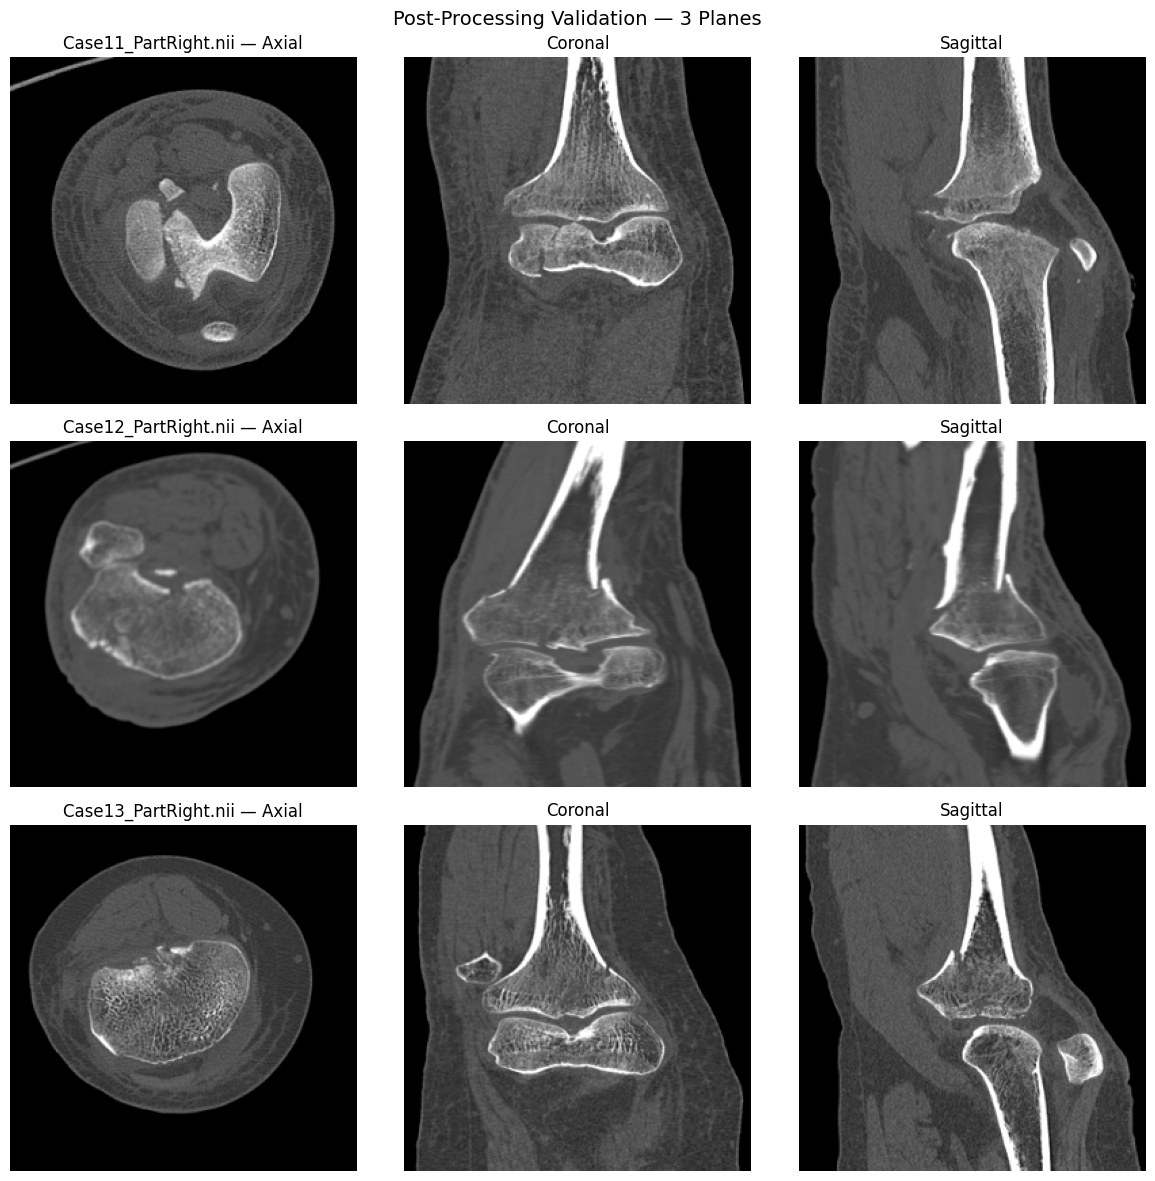

In [10]:
print("Validating saved volumes...\n")

saved_files = sorted(OUTPUT_DIR.glob("*.nii.gz"))
n_check = min(3, len(saved_files))

for fpath in saved_files[:n_check]:
    vol = sitk.ReadImage(str(fpath))
    arr = sitk.GetArrayFromImage(vol)
    sp  = vol.GetSpacing()

    shape_ok    = arr.shape == TARGET_SIZE
    range_ok    = arr.min() >= -0.01 and arr.max() <= 1.01

    status = "✅" if (shape_ok and range_ok) else "❌"
    print(f"{status} {fpath.name}")
    print(f"   Shape   : {arr.shape}  (expect {TARGET_SIZE})  {'✓' if shape_ok else '✗'}")
    print(f"   Spacing : {sp}")
    print(f"   Range   : [{arr.min():.4f}, {arr.max():.4f}]  {'✓' if range_ok else '✗'}")
    print()

# Visualize 3 planes for up to 3 samples
fig, axes = plt.subplots(n_check, 3, figsize=(12, 4 * n_check))
if n_check == 1:
    axes = axes[np.newaxis, :]

for i, fpath in enumerate(saved_files[:n_check]):
    arr = sitk.GetArrayFromImage(sitk.ReadImage(str(fpath)))
    mid = [s // 2 for s in arr.shape]

    axes[i, 0].imshow(arr[mid[0], :, :], cmap="gray", vmin=0, vmax=1)
    axes[i, 0].set_title(f"{fpath.stem} — Axial")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(arr[:, mid[1], :], cmap="gray", vmin=0, vmax=1)
    axes[i, 1].set_title("Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(arr[:, :, mid[2]], cmap="gray", vmin=0, vmax=1)
    axes[i, 2].set_title("Sagittal")
    axes[i, 2].axis("off")

plt.suptitle("Post-Processing Validation — 3 Planes", fontsize=14)
plt.tight_layout()
plt.show()

## Cell 11 — Pipeline Summary & Next Steps

### Summary
- **Input**: Raw DICOM CT volumes from `data/raw/fractured/{PartLeft,PartRight}`
- **Output**: Standardized NIfTI volumes in `data/interim/predrr/`
- **Pipeline**: Resample (0.5mm) → Orient (LAS) → Window ([-450,1050] HU) → ROI Crop → Resize (256³)

### Next Steps
1. Proceed to **`drr.ipynb`** to generate bi-planar DRRs from the preprocessed volumes
2. When the **healthy knee dataset** is available, add it to `data/raw/healthy/` and extend Cell 2 with knee-region z-range extraction before running the same pipeline

> **Note**: Target resolution (256³ @ 0.5mm) is temporary and may be adjusted based on model requirements.